In [1]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim

/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import make_moons


class TwoMoonsDataset(Dataset):
    def __init__(self, n_samples=1000, noise=0.05, seq_len=4):
        X, _ = make_moons(n_samples=n_samples, noise=noise)

        self.X = torch.tensor(X, dtype=torch.float32)
        self.seq_len = seq_len
        self.drift_noise = 0.05
        self.diffusion_rate = 1.1
        x_max = X.max(axis=0)
        x_min = X.min(axis=0)
        self.X = (self.X - x_min) / (x_max - x_min)
        self.rollout_len = 10

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        x_seq = torch.zeros(self.seq_len, 2)
        initial_index = torch.randint(0, self.rollout_len - self.seq_len, (1,))
        for i in range(self.seq_len):
            x_seq[i] = x * self.diffusion_rate ** (initial_index + i)
        return x_seq % 1

    def get_x_at_i(self, i):
        return (self.X * self.diffusion_rate ** i) % 1

    def get_X_from_i(self, i):
        random_index = torch.randint(0, self.X.shape[0], (1,))
        return torch.stack([(self.X[random_index] * self.diffusion_rate ** (i + j)) % 1 for j in range(self.seq_len)]).reshape(1, self.seq_len, 2).to(torch.float32)

# create dataset
dataset = TwoMoonsDataset(n_samples=10_000, noise=0.1)

# create dataloader
dataloader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True,
    drop_last=False
)

# example usage
for x in dataloader:
    print(x.shape)
    break


torch.Size([256, 4, 2])


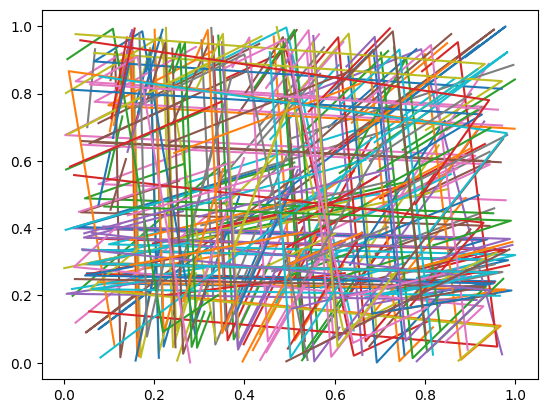

In [3]:
import matplotlib.pyplot as plt
for item in x:
    plt.plot(item[:, 0], item[:, 1])
plt.show()

In [4]:
state_dim = 2

# dynamic_model = DynamicFlowModel(
#     input_dim=state_dim,
#     conditioning_dim=3*state_dim,
#     output_dim=state_dim,
#     time_embed_dim=16,
#     hidden_dim=128,
#     depth=2,
#     use_layer_norm=True,
# )

dynamic_model = DynamicAttentionalFlowModel(
    input_dim=state_dim,
    conditioning_dim=state_dim,
    output_dim=state_dim,
    num_heads=4,
    hidden_dim=256,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

In [5]:
from reflect.utils import (
    AdamOptim,
)

optimizer = optim.Adam(dynamic_model.parameters(), lr=1e-3)

In [6]:
time_coeff = 0

In [7]:
def _update(
        x: torch.Tensor,
        flow_model: DynamicFlowModel,
    ):
    optimizer.zero_grad()
    b, l, d = x.shape
    t = torch.rand(b, 1, 1, device=x.device)

    x_sample = torch.randn(b, 1, d)
    x_cond = x[:, 0:3]
    x_real = x[:, 3:]

    x_interp = (1 - t) * x_sample + t * x_real
    v = (x_real - x_sample).reshape(b, d)
    u = dynamic_model.forward(x_cond, x_interp, t)
    u_loss = ((u - v) ** 2).mean()
    loss = u_loss
    loss.backward()
    optimizer.step()

    rel_err = (
        (u - v).norm(dim=1)
        / (v.norm(dim=1) + 1e-4)
    ).mean()
    return {
        'flow_loss': u_loss.item(),
        'rel_err': rel_err.item()
    }

In [8]:
for batch in dataloader:
    losses = _update(batch, dynamic_model)
    break

In [9]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
  },
)

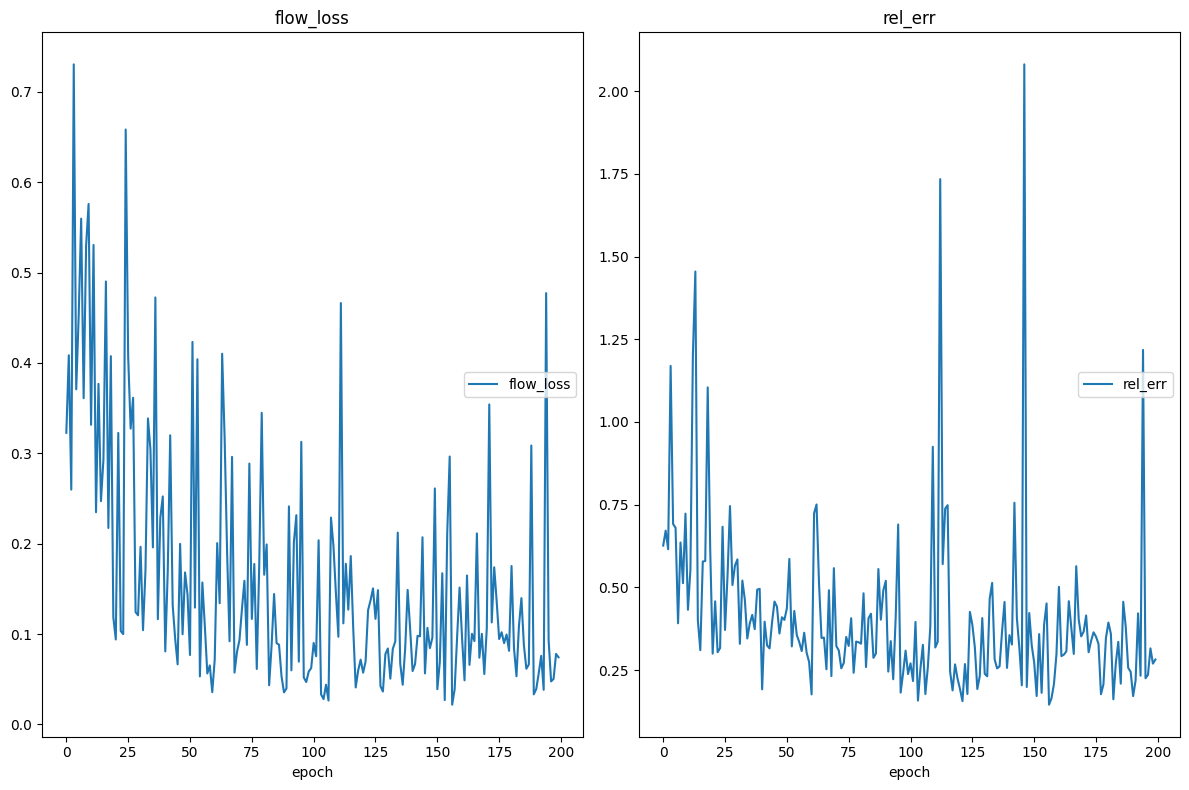

flow_loss
	flow_loss        	 (min:    0.022, max:    0.731, cur:    0.074)
rel_err
	rel_err          	 (min:    0.145, max:    2.081, cur:    0.282)


In [10]:
for epoch in range(200):
    total_loss = 0.0
    total_rel_err = 0.0
    for batch in dataloader:
        losses = _update(batch, dynamic_model)
        total_loss += losses['flow_loss']
        total_rel_err += losses['rel_err']
    print(f"Epoch {epoch:03d} | loss = {total_loss / len(dataloader):.4f} | rel_err = {total_rel_err / len(dataloader):.4f}")
    plot_losses.update(losses)
    plot_losses.send()


In [11]:
import matplotlib.pyplot as plt

In [12]:
import numpy as np

def plot_vector_field():
    random_idx = np.random.randint(0, len(dataloader.dataset))
    x = dataset[random_idx]
    
    # square bounds around `data
    l = 4
    padding = 0.5
    grid_size = 50
    device='cpu'
    X = dataloader.dataset.X
    mins, _ = X.min(dim=0)
    maxs, _ = X.max(dim=0)
    center = (mins + maxs) / 2
    half_side = torch.max((maxs - mins) / 2).item() + padding

    x_min, x_max = (center[0].item() - half_side), (center[0].item() + half_side)
    y_min, y_max = (center[1].item() - half_side), (center[1].item() + half_side)

    # mesh
    xs = torch.linspace(x_min, x_max, grid_size, device=device)
    ys = torch.linspace(y_min, y_max, grid_size, device=device)
    xx, yy = torch.meshgrid(xs, ys, indexing="xy")              # (G,G)
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1) # (G*G,2)
    grid = grid.unsqueeze(1)
    # time broadcast (common convention: (B,) )
    a = torch.empty(grid.shape[0], 1, 0, device=device)

    fig, axs = plt.subplots(ncols=5, figsize=(20, 12))
    for i, t in enumerate([0, 0.25, 0.5, 0.75, 1]):
        tt = torch.full((grid.shape[0], 1, 1), float(t), device=device)
        # eval
        dynamic_model.eval()
        with torch.no_grad():
            x_cond = x[0:3][None].repeat(grid.shape[0], 1, 1)
            v = dynamic_model(x_cond, grid, tt)  # expected (G*G,2)

        v = v.reshape(grid_size, grid_size, 2)

        xx, yy, v = xx.detach().cpu(), yy.detach().cpu(), v.detach().cpu()

        u = v[..., 0]
        w = v[..., 1]

        axs[i].quiver(
            xx.numpy(),
            yy.numpy(),
            u.numpy(),
            w.numpy(),
            angles="xy",
            scale_units="xy",
            scale=10,
        )

        axs[i].set_aspect("equal")
        axs[i].set_xlabel("x1")
        axs[i].set_ylabel("x2")
        axs[i].grid(alpha=0.3)

        X = dataloader.dataset.get_x_at_i(4)
        axs[i].scatter(X[:1000, 0], X[:1000, 1], s=10, c="red", alpha=0.1)
        axs[i].plot(x[:, 0], x[:, 1], c="green", alpha=0.5)

    plt.show()

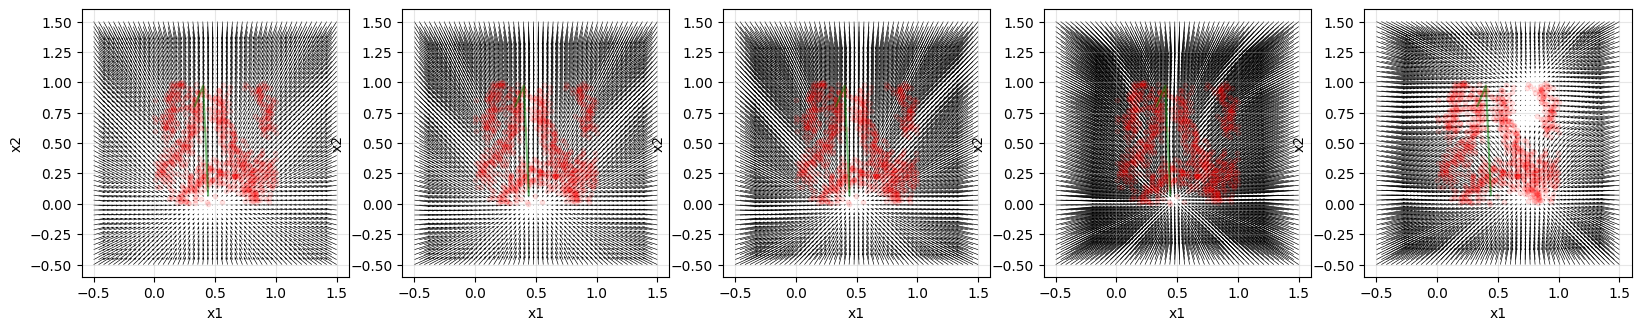

In [13]:
plot_vector_field()

In [14]:
def _step(
        flow_model: DynamicFlowModel,
        x_cond: torch.Tensor,
        x: torch.Tensor,
        t: torch.Tensor,
        delta: float,
        step_type: str = 'euler',
    ):    
    a = torch.empty(1, 1, 0, device=x.device)
    if step_type == 'euler':
        u = flow_model.forward(x_cond, x, t)
        x_next = x + u * delta
        return x_next, t + delta
    else:
        raise ValueError(f'Invalid step type: {step_type}')

In [15]:
def get_trajectory(num_steps=100, i=0):
    x = dataset.get_X_from_i(i)
    x_cond = x[:, 0:3]
    i = torch.randn(1, 1, 2)
    t = torch.zeros(1, 1, 1)
    trajectory = torch.zeros(num_steps, 1, 2)
    delta = 1/num_steps
    step_type = 'euler'
    for step in range(num_steps):
        trajectory[step] = i
        i, t = _step(dynamic_model, x_cond, i, t, delta, step_type)
    trajectory[step] = i

    return trajectory.detach(), x

In [16]:
trajectory, _ = get_trajectory()
trajectory.shape

torch.Size([100, 1, 2])

100%|██████████| 100/100 [00:33<00:00,  3.02it/s]


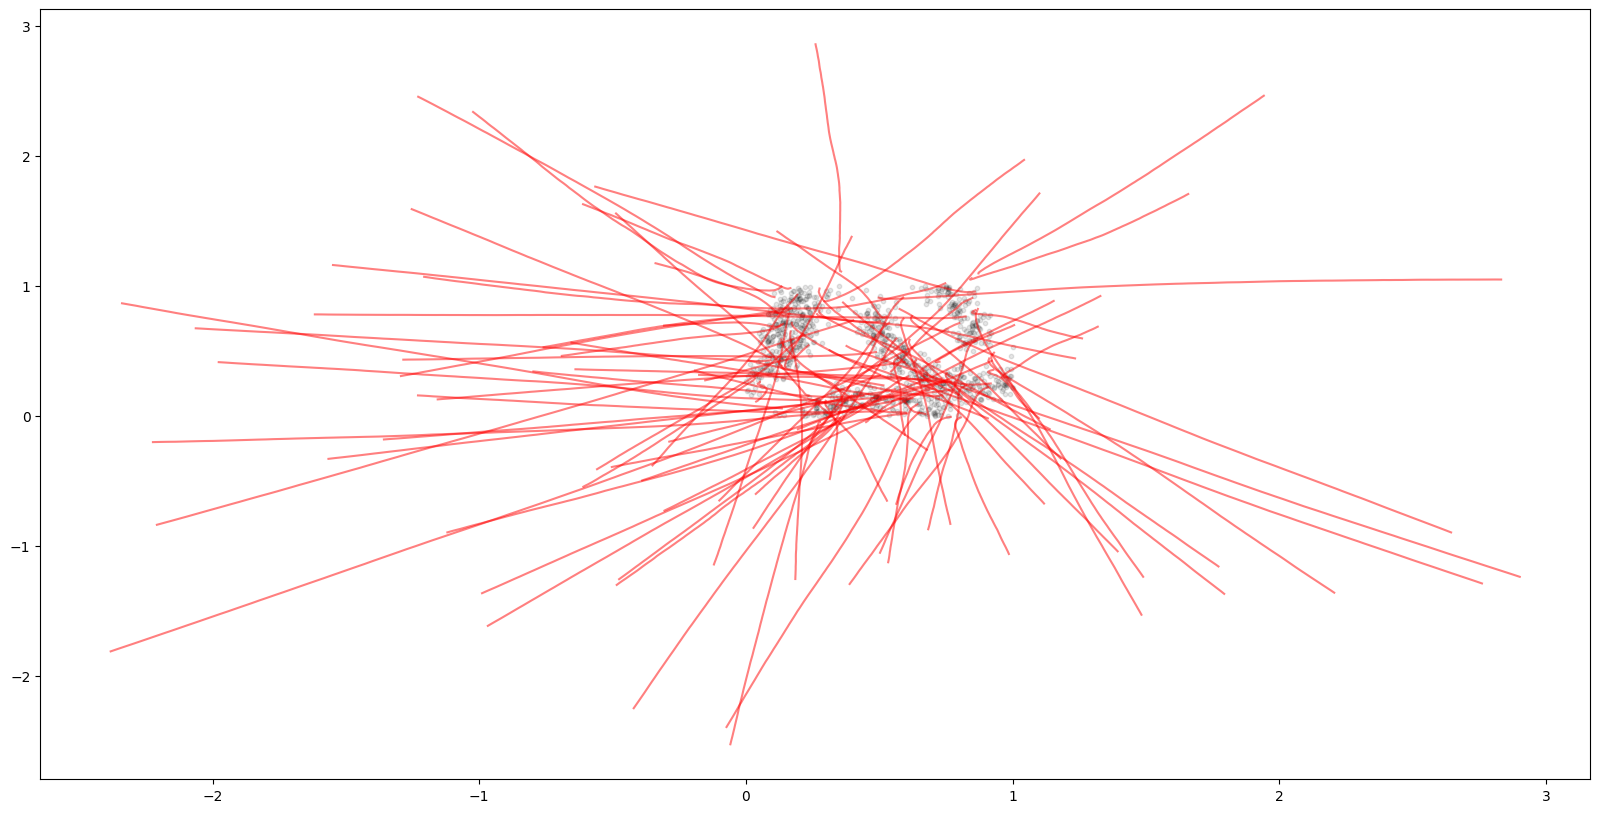

In [17]:
fig, axs = plt.subplots(figsize=(20, 10))
X_i = dataloader.dataset.get_x_at_i(3)
axs.scatter(X_i[:1000, 0], X_i[:1000, 1], s=10, c="black", alpha=0.1)

for i in tqdm(range(100)):
    trajectory, _ = get_trajectory()
    axs.plot(trajectory[:, 0, 0], trajectory[:, 0, 1], c="red", alpha=0.5)
plt.show()



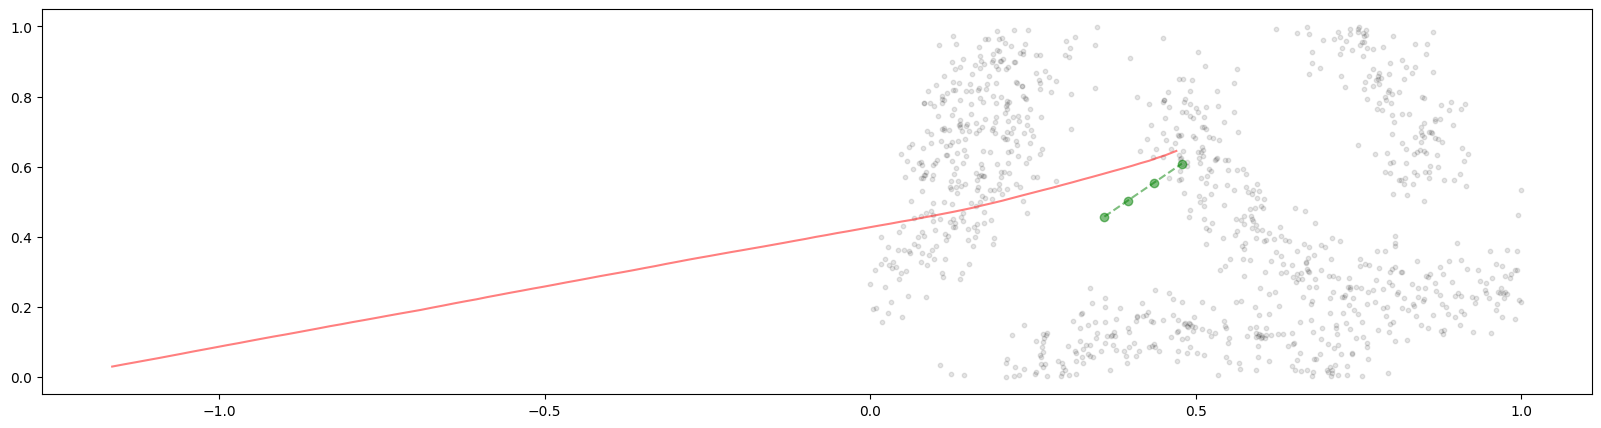

In [18]:
fig, axs = plt.subplots(figsize=(20, 5))
X_i = dataloader.dataset.get_x_at_i(3)
axs.scatter(X_i[:1000, 0], X_i[:1000, 1], s=10, c="black", alpha=0.1)

trajectory, orb = get_trajectory()
axs.plot(trajectory[:, 0, 0], trajectory[:, 0, 1], c="red", alpha=0.5)
axs.plot(orb[0, :, 0], orb[0, :, 1], c="green", alpha=0.5, linestyle="--", marker="o")
plt.show()

In [19]:
dps = []
for _ in tqdm(range(1000)):
    trajectory, _ = get_trajectory(i=3)
    dps.append([trajectory[-1, :, 0], trajectory[-1, :, 1]])

100%|██████████| 1000/1000 [07:59<00:00,  2.08it/s]


In [20]:
dps_c = torch.cat([torch.cat([d.unsqueeze(0) for d in dp]).unsqueeze(0) for dp in dps])

In [21]:
dps_c.shape

torch.Size([1000, 2, 1])

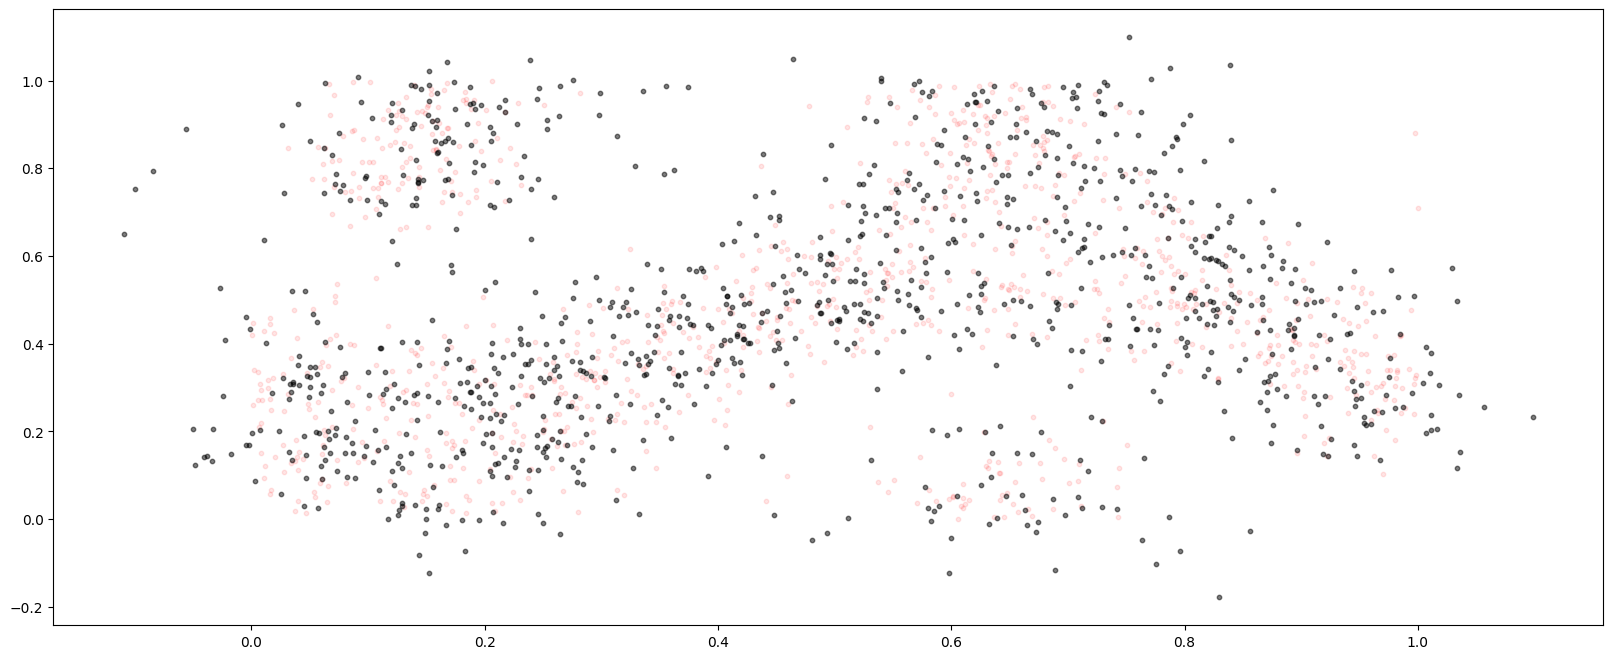

In [22]:
fig, axs = plt.subplots(figsize=(20, 8))
X_i = dataloader.dataset.get_x_at_i(6)
axs.scatter(X_i[:1000, 0], X_i[:1000, 1], s=10, c="red", alpha=0.1)
axs.scatter(dps_c[:, 0], dps_c[:, 1], s=10, c="black", alpha=0.5)
plt.show()
